# Exploratory Data Analysis
## Netflix Movies & TV Shows

For this project I'm using the Netflix Movies and TV Shows dataset from Kaggle (originally put together by Shivam Bansal). It's a list of about 7,800 titles on Netflix with details like type, director, cast, country, when it was added, release year, rating, duration and genre.

I picked this one mainly because everyone has used Netflix so the questions feel natural to ask, and it's a decent dataset to practice cleaning on - directors and countries are missing a lot, and a couple of columns (country, genre) can hold more than one value per row.

Dataset: https://www.kaggle.com/datasets/shivamb/netflix-shows

Questions I want to answer:
- Does Netflix have more movies or TV shows?
- How has the amount of content added grown over the years?
- Which countries produce the most content?
- What genres show up most often?
- How long is a typical movie, and how many seasons does a typical show get?
- Is the catalog mostly mature rated or family rated?

# Downloading the Dataset

Reading straight from a GitHub mirror of the dataset so this runs end to end without a Kaggle API key.

In [1]:
import pandas as pd
import numpy as np

netflix_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2021/2021-04-20/netflix_titles.csv'
df = pd.read_csv(netflix_url)
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [2]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

Quick column reference:

| Column | Meaning |
|---|---|
| show_id | unique id for the title |
| type | Movie or TV Show |
| title | name of the title |
| director | director(s) |
| cast | main actors |
| country | country/countries of production |
| date_added | date the title was added to Netflix |
| release_year | year the title was originally released |
| rating | content/age rating, e.g. TV-MA, PG-13 |
| duration | length in minutes (movies) or seasons (TV shows) |
| listed_in | genre(s) |
| description | short plot summary |

# Data Cleaning and Processing

Don't need every column for this, so picking out just the ones I'll actually use.

In [3]:
selected_columns = [
    #Content info
    'type',
    'title',
    'director',
    'cast',
    'country',
    #Release info
    'date_added',
    'release_year',
    'rating',
    'duration',
    'listed_in'
]

In [4]:
len(selected_columns)

10

In [5]:
netflix_df= df[selected_columns].copy()
netflix_df

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies"
2,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies"
3,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas
...,...,...,...,...,...,...,...,...,...,...
7782,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies"
7783,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals"
7784,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M..."
7785,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV"


In [6]:
netflix_df.shape

(7787, 10)

In [7]:
netflix_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          7787 non-null   str  
 1   title         7787 non-null   str  
 2   director      5398 non-null   str  
 3   cast          7069 non-null   str  
 4   country       7280 non-null   str  
 5   date_added    7777 non-null   str  
 6   release_year  7787 non-null   int64
 7   rating        7780 non-null   str  
 8   duration      7787 non-null   str  
 9   listed_in     7787 non-null   str  
dtypes: int64(1), str(9)
memory usage: 608.5 KB


In [8]:
netflix_df.isnull().sum()

type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
dtype: int64

director (2,389 missing), cast (718) and country (507) have a lot of gaps - pretty normal, Netflix's metadata is just incomplete for a lot of older titles. Filling these with 'Unknown' instead of dropping the rows so I don't lose the rest of the title's info.

In [9]:
netflix_df['director']=netflix_df['director'].fillna('Unknown')
netflix_df['cast']=netflix_df['cast'].fillna('Unknown')
netflix_df['country']=netflix_df['country'].fillna('Unknown')
netflix_df['rating']=netflix_df['rating'].fillna('Unknown')

netflix_df.isnull().sum()

type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
dtype: int64

Only date_added still has nulls left (10 rows). Can't really guess a date for those so just dropping them.

In [10]:
netflix_df.drop(netflix_df[netflix_df.date_added.isnull()].index,inplace=True)
netflix_df.isnull().sum()

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [11]:
netflix_df.duplicated().sum()

np.int64(0)

No duplicates. Adding two columns that'll make the analysis easier later:
- year_added, pulled out of date_added
- duration_value, just the number part of duration (minutes for movies, seasons for shows)

In [12]:
netflix_df['date_added']=netflix_df['date_added'].str.strip()
netflix_df['year_added']=pd.to_datetime(netflix_df['date_added'],errors='coerce').dt.year
netflix_df['duration_value']=netflix_df['duration'].str.extract(r'(\d+)').astype(float)

netflix_df[['title','type','date_added','year_added','duration','duration_value']]

,title,type,date_added,year_added,duration,duration_value
0,3%,TV Show,"August 14, 2020",2020,4 Seasons,4.0
1,7:19,Movie,"December 23, 2016",2016,93 min,93.0
2,23:59,Movie,"December 20, 2018",2018,78 min,78.0
3,9,Movie,"November 16, 2017",2017,80 min,80.0
4,21,Movie,"January 1, 2020",2020,123 min,123.0
...,...,...,...,...,...,...
7782,Zozo,Movie,"October 19, 2020",2020,99 min,99.0
7783,Zubaan,Movie,"March 2, 2019",2019,111 min,111.0
7784,Zulu Man in Japan,Movie,"September 25, 2020",2020,44 min,44.0
7785,Zumbo's Just Desserts,TV Show,"October 31, 2020",2020,1 Season,1.0


In [13]:
netflix_df.describe()

,release_year,year_added,duration_value
count,7777.000000,7777.000000,7777.000000
mean,2013.935965,2018.493378,69.204706
std,8.760694,1.388144,50.931983
min,1925.000000,2008.000000,1.000000
25%,2013.000000,2018.000000,2.000000
50%,2017.000000,2019.000000,88.000000
75%,2018.000000,2020.000000,106.000000
max,2021.000000,2021.000000,312.000000


# Data visualization

In [14]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

sns.set_style('darkgrid')

matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Movies vs TV Shows

In [15]:
type_counts=netflix_df.type.value_counts()
type_counts

type
Movie      5377
TV Show    2400
Name: count, dtype: int64

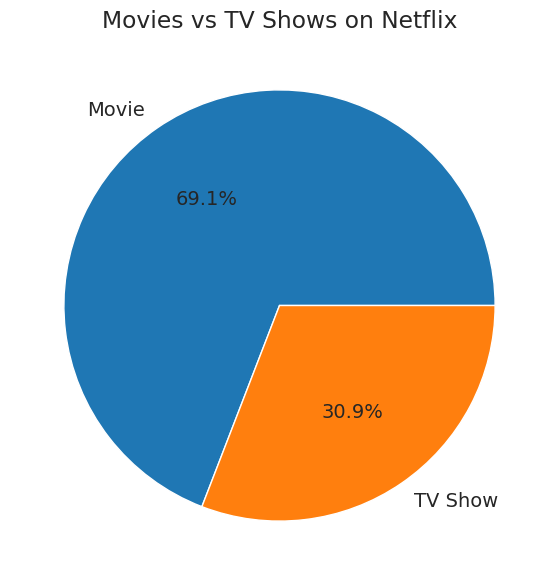

In [16]:
plt.figure(figsize=(7,7))
plt.title('Movies vs TV Shows on Netflix')
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%')
plt.show()

## Catalog Growth Over the Years

In [17]:
yearly_added=netflix_df.year_added.value_counts().sort_index()
yearly_added

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      25
2015      88
2016     443
2017    1225
2018    1685
2019    2153
2020    2009
2021     117
Name: count, dtype: int64

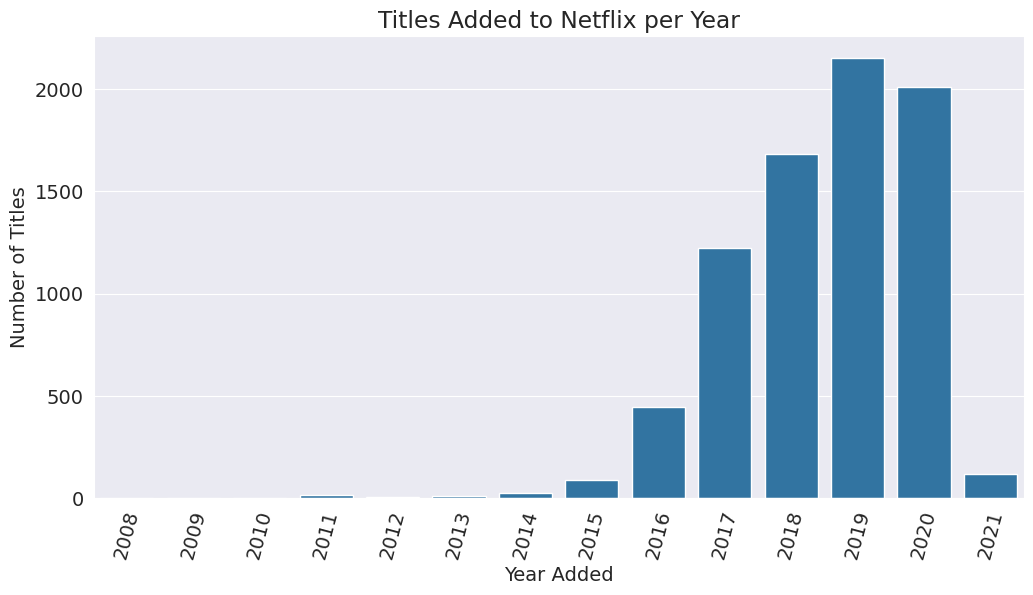

In [18]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.barplot(x=yearly_added.index,y=yearly_added.values)
plt.title('Titles Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

## Top Countries

country can have multiple comma-separated countries for co-productions, so a plain value_counts() would lump "India, United States" together instead of counting each separately. Wrote a small helper that explodes a column like this into one True/False column per option (same idea I'll reuse for genre below).

In [19]:
def split_multicolumn(col_series,sep=', '):
    options_dict = {}
    for idx, value in col_series[col_series.notnull()].items():
        for option in str(value).split(sep):
            if option not in options_dict:
                options_dict[option] = pd.Series(False, index=col_series.index)
            options_dict[option].loc[idx] = True
    return pd.concat(options_dict, axis=1)

In [20]:
country_df=split_multicolumn(netflix_df.country)
country_totals=country_df.sum().sort_values(ascending=False)
country_totals=country_totals.drop('Unknown',errors='ignore')
top_countries=country_totals.head(10)
top_countries

United States     3290
India              990
United Kingdom     721
Canada             412
France             349
Japan              286
Spain              215
South Korea        212
Germany            199
Mexico             154
dtype: int64

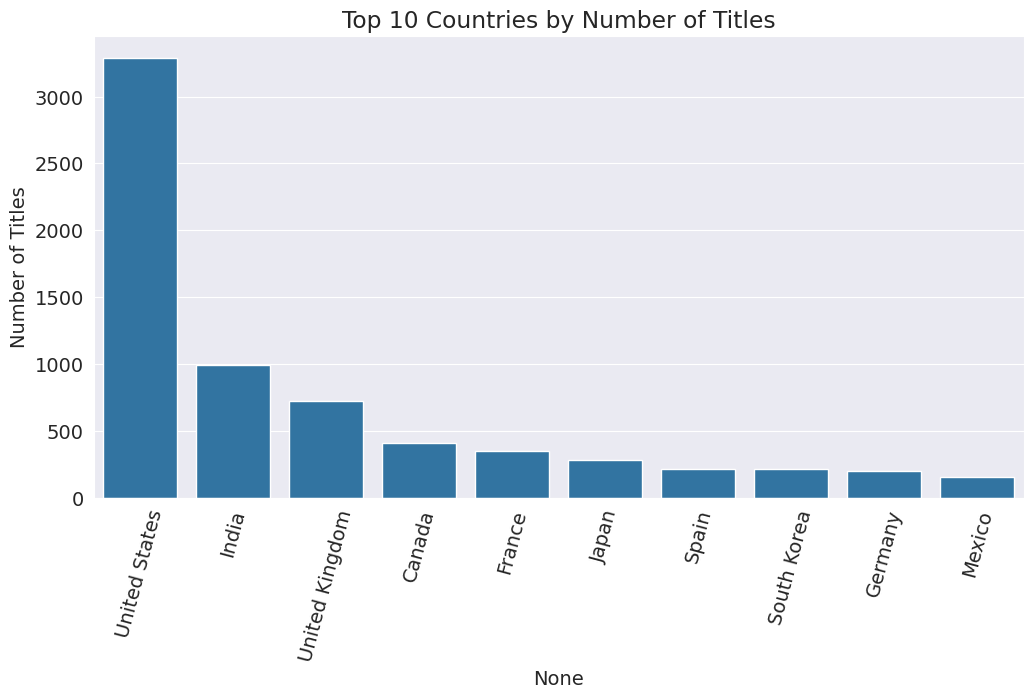

In [21]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.barplot(x=top_countries.index,y=top_countries.values)
plt.title('Top 10 Countries by Number of Titles')
plt.ylabel('Number of Titles')
plt.show()

## Top Genres

listed_in has the same multi-value setup as country, so reusing split_multicolumn here too.

In [22]:
genre_df=split_multicolumn(netflix_df.listed_in)
genre_totals=genre_df.sum().sort_values(ascending=False)
top_genres=genre_totals.head(10)
top_genres

International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1198
Documentaries                786
Action & Adventure           721
TV Dramas                    703
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
dtype: int64

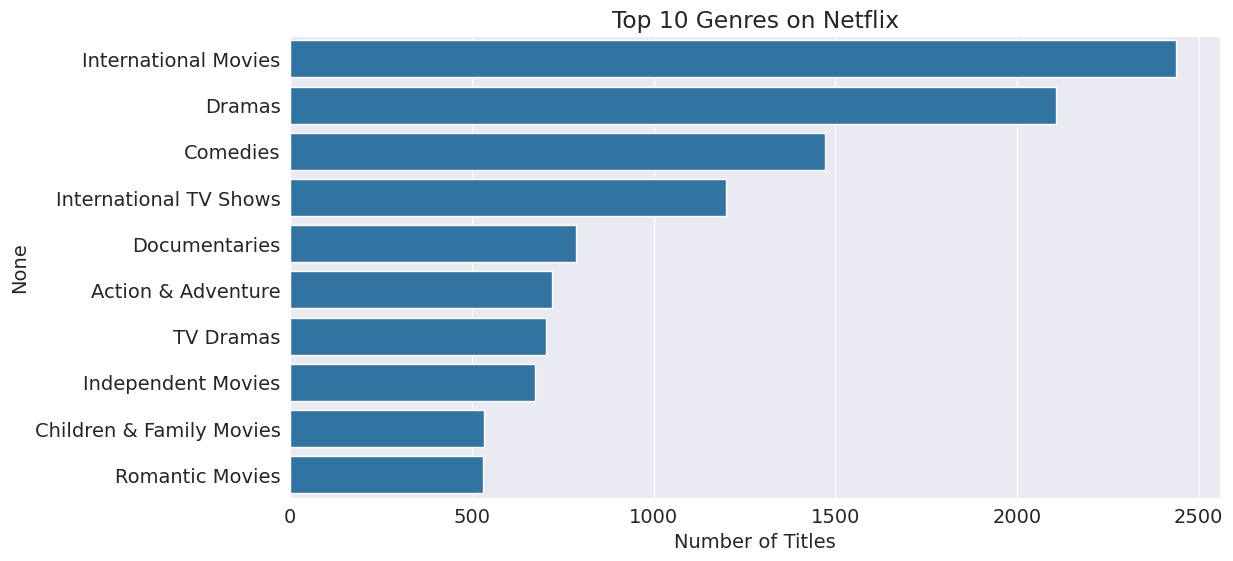

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values,y=top_genres.index)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.show()

## Movie Duration

In [24]:
movies=netflix_df[netflix_df.type=='Movie']
movies.duration_value.describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64

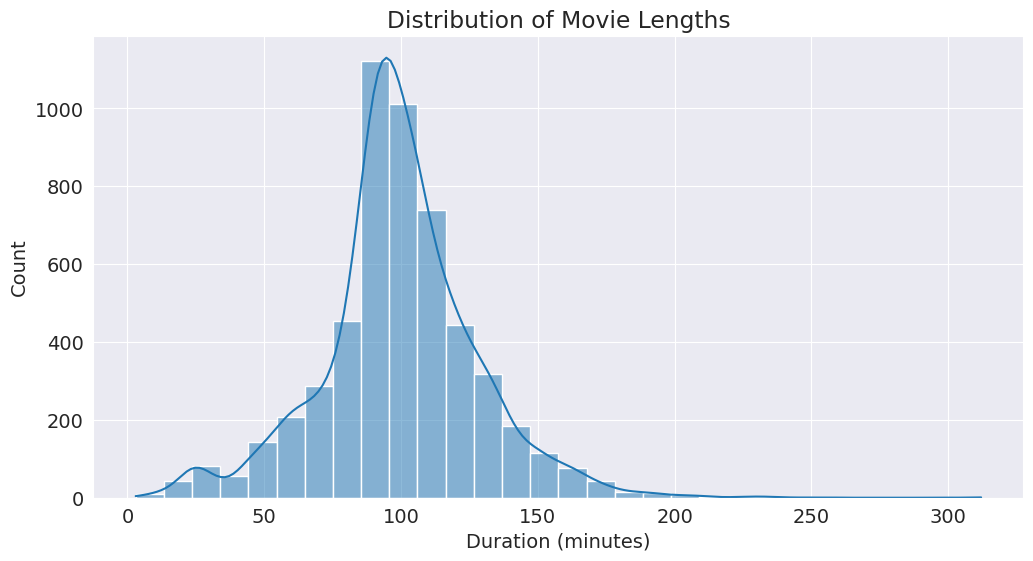

In [25]:
plt.figure(figsize=(12,6))
plt.title('Distribution of Movie Lengths')
plt.xlabel('Duration (minutes)')
sns.histplot(movies.duration_value,bins=30,kde=True)
plt.show()

## Content Ratings

In [26]:
rating_counts=netflix_df[netflix_df.rating!='Unknown'].rating.value_counts()
rating_counts.head(8)

rating
TV-MA    2861
TV-14    1928
TV-PG     804
R         665
PG-13     386
TV-Y      279
TV-Y7     270
PG        247
Name: count, dtype: int64

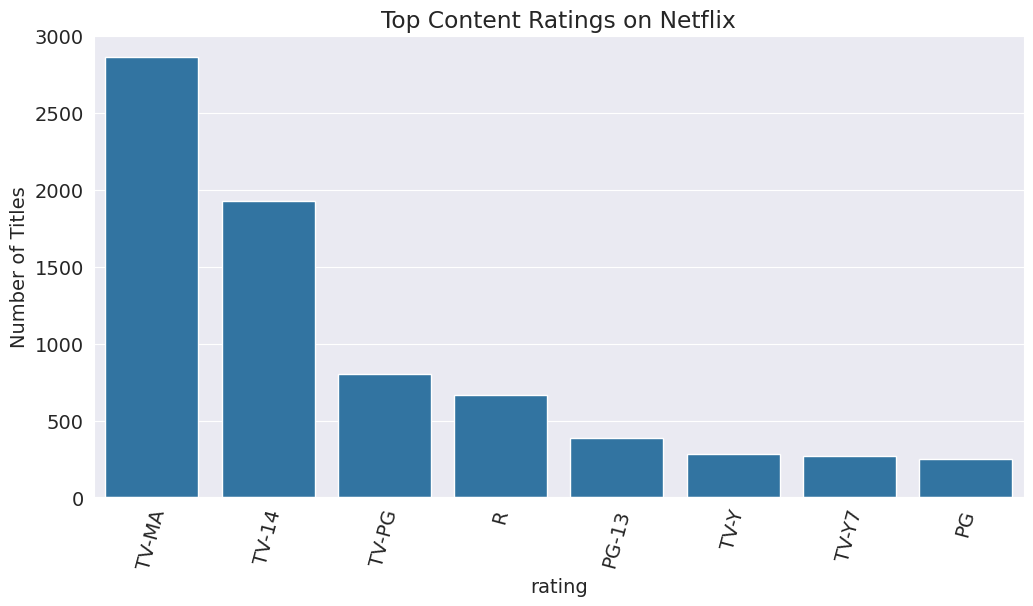

In [27]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
sns.barplot(x=rating_counts.head(8).index,y=rating_counts.head(8).values)
plt.title('Top Content Ratings on Netflix')
plt.ylabel('Number of Titles')
plt.show()

# Asking and Answering Questions

Going back through the questions from the top of the notebook with the actual numbers.

### Q1: Does Netflix have more Movies or TV Shows, and by how much?

In [28]:
(netflix_df.type.value_counts(normalize=True)*100).round(1)

type
Movie      69.1
TV Show    30.9
Name: proportion, dtype: float64

Movies make up about 69% of the catalog, TV shows the other 31%. So roughly 2 movies for every show.

### Q2: How has the amount of content added to Netflix grown over the years?

In [29]:
yearly_added.tail(7)

year_added
2015      88
2016     443
2017    1225
2018    1685
2019    2153
2020    2009
2021     117
Name: count, dtype: int64

Barely anything before 2015, then it really takes off - title additions go from 443 in 2016 to a peak of 2,153 in 2019. Lines up with when Netflix went all in on international expansion and original content.

### Q3: Which countries produce the most content on Netflix?

In [30]:
top_countries.head(5)

United States     3290
India              990
United Kingdom     721
Canada             412
France             349
dtype: int64

US is way out in front, then India and the UK. Makes sense given Netflix is American and India has such a massive film industry.

### Q4: What are the most common genres on Netflix?

In [31]:
top_genres.head(5)

International Movies      2437
Dramas                    2106
Comedies                  1471
International TV Shows    1198
Documentaries              786
dtype: int64

International Movies is the single biggest genre tag, then Dramas and Comedies. Fits with Netflix pushing localized content everywhere instead of just English-language stuff.

### Q5: How long is a typical Netflix movie, and how many seasons does a typical TV show have?

In [32]:
tv=netflix_df[netflix_df.type=='TV Show']

print('Average movie length:',round(movies.duration_value.mean(),1),'minutes')
print('Median movie length:',round(movies.duration_value.median()),'minutes')
print('Average TV show seasons:',round(tv.duration_value.mean(),2))
print('Share of shows with just 1 season:',round((tv.duration_value==1).mean()*100,1),'%')

Average movie length: 99.3 minutes
Median movie length: 98 minutes
Average TV show seasons: 1.76
Share of shows with just 1 season: 67.0 %


Average movie is about 99 minutes. TV shows are mostly short-lived though - average of 1.78 seasons, and 67% of all shows never make it past season 1.

### Q6: Is most of Netflix's content rated for mature audiences or for families?

In [33]:
mature_ratings=['TV-MA','R','NC-17']
family_ratings=['TV-Y','TV-Y7','TV-G','G','TV-PG','PG']

mature_count=netflix_df.rating.isin(mature_ratings).sum()
family_count=netflix_df.rating.isin(family_ratings).sum()
total_rated=netflix_df[netflix_df.rating!='Unknown'].shape[0]

print('Mature-rated titles:',mature_count,'(',round(mature_count/total_rated*100,1),'%)')
print('Family-rated titles:',family_count,'(',round(family_count/total_rated*100,1),'%)')

Mature-rated titles: 3529 ( 45.4 %)
Family-rated titles: 1833 ( 23.6 %)


Mature-rated titles (TV-MA / R / NC-17) are about 45% of everything that has a rating, more than double any single family rating. Catalog definitely leans toward adults and teens, not little kids.

# Inferences and Conclusion

What stood out:
- Movies dominate the catalog, roughly 69/31 over TV shows.
- Catalog growth exploded between 2016 and 2019 (over 2,000 titles added in 2019 alone), then slowed down.
- US, India and UK produce the most content, with the US way ahead of everyone else.
- International Movies, Dramas and Comedies are the most common genres - a pretty global, localized content strategy.
- Most TV shows never get past one season, about two thirds of them.
- The catalog skews mature overall, TV-MA is the single most common rating.

Things I'd look into with more time:
- a more recent snapshot of the catalog, this one only goes up to mid-2021
- some text analysis on the description column
- which actors/directors show up the most across titles

References:
- Dataset: https://www.kaggle.com/datasets/shivamb/netflix-shows (mirrored via TidyTuesday)
- pandas docs: https://pandas.pydata.org/docs/
- seaborn docs: https://seaborn.pydata.org/